# RTX 5070 Ti — roofline

Regenerates `assets/images/rtx5070ti-roofline.{png,svg}` for the GPU-bottlenecks post.

All inputs are the card's FP32 specs (the same numbers as the post's spec table). Edit the
toggles in the first cell: `SHOW_NAIVE` draws the red naive-matmul dot; `TENSOR_CEILINGS`
adds higher-precision (FP16/FP4) ceilings for a closing figure. Default is a clean FP32-only plot.

Lives in `_notebooks/`, so Jekyll never publishes it.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# --- RTX 5070 Ti specs (FP32 / CUDA cores) ---
FP32_TFLOPS = 44.0     # 8960 lanes x 2.45 GHz x 2 (FMA)
BW_GBPS     = 896.0    # GDDR7, 256-bit
RIDGE       = FP32_TFLOPS * 1e12 / (BW_GBPS * 1e9)   # ~49 FLOP/byte

# --- what to draw ---
SHOW_NAIVE = True      # red naive-matmul dot
NAIVE_AI   = 0.25      # FLOP/byte

# Optional higher-precision tensor-core ceilings. Empty dict = FP32-only plot.
# Fill with REAL spec numbers in TFLOP/s if you want a closing figure; do not guess.
TENSOR_CEILINGS = {
    # 'FP16/BF16 tensor (dense)': 0.0,
    # 'FP4 tensor (sparse)':      0.0,
}

wrote /home/ouha0/Documents/Hai/ouha0.github.io/assets/images/rtx5070ti-roofline.png and /home/ouha0/Documents/Hai/ouha0.github.io/assets/images/rtx5070ti-roofline.svg


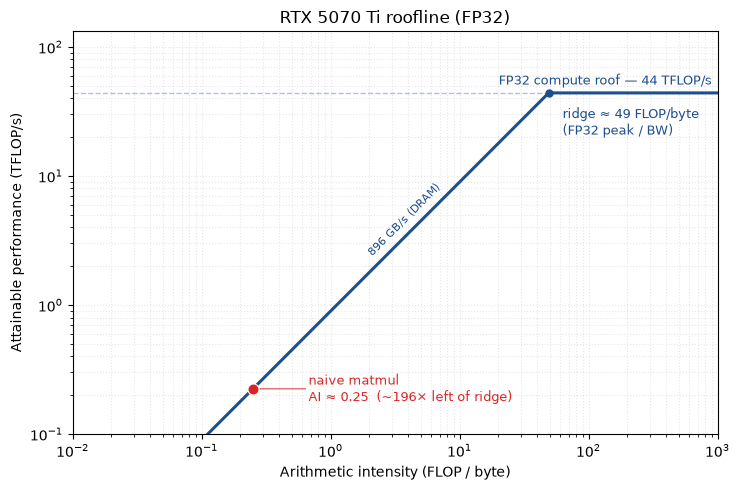

In [4]:
BW = BW_GBPS / 1000.0          # TFLOP/s per FLOP/byte along the memory diagonal
ai = np.logspace(-2, 3, 600)
roofline = np.minimum(BW * ai, FP32_TFLOPS)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.loglog(ai, roofline, color='#1f4e8c', lw=2.2, zorder=3)
ax.axhline(FP32_TFLOPS, color='#1f4e8c', lw=1, ls='--', alpha=0.35)

# ridge
ax.plot(RIDGE, FP32_TFLOPS, 'o', color='#1f4e8c', ms=5, zorder=4)
ax.annotate(f'ridge ≈ {RIDGE:.0f} FLOP/byte\n(FP32 peak / BW)', (RIDGE, FP32_TFLOPS),
            xytext=(10, -30), textcoords='offset points', fontsize=9, color='#1f4e8c')
ax.annotate(f'FP32 compute roof — {FP32_TFLOPS:.0f} TFLOP/s', (ai[-1], FP32_TFLOPS),
            xytext=(-4, 6), textcoords='offset points', ha='right', fontsize=9, color='#1f4e8c')

# optional higher-precision ceilings (closing figure)
for label, peak in TENSOR_CEILINGS.items():
    if not peak:
        continue
    ax.axhline(peak, color='#888', lw=1, ls=':')
    ax.annotate(f'{label} — {peak:g} TFLOP/s', (ai[0], peak), xytext=(2, 4),
                textcoords='offset points', fontsize=8, color='#888')

# naive matmul — dot stays on the diagonal (it runs at the bandwidth ceiling);
# label pushed clear to the right with a thin leader so it no longer crosses the line
if SHOW_NAIVE:
    y = BW * NAIVE_AI
    ax.plot(NAIVE_AI, y, 'o', color='#d62728', ms=8, zorder=5,
            markeredgecolor='white', markeredgewidth=0.8)
    ax.annotate(f'naive matmul\nAI ≈ {NAIVE_AI}  (~{RIDGE/NAIVE_AI:.0f}× left of ridge)',
                xy=(NAIVE_AI, y), xytext=(40, 0), textcoords='offset points',
                ha='left', va='center', fontsize=9, color='#d62728',
                arrowprops=dict(arrowstyle='-', color='#d62728', lw=0.7, shrinkA=0, shrinkB=3))

ax.set_xlabel('Arithmetic intensity (FLOP / byte)')
ax.set_ylabel('Attainable performance (TFLOP/s)')
ax.set_title('RTX 5070 Ti roofline (FP32)')
ax.grid(True, which='both', ls=':', alpha=0.3)
ax.set_xlim(1e-2, 1e3)
ytop = max([FP32_TFLOPS] + [p for p in TENSOR_CEILINGS.values() if p]) * 3
ax.set_ylim(1e-1, ytop)
fig.tight_layout()
fig.canvas.draw()   # finalize transforms before measuring the diagonal's screen angle

# 896 GB/s label, rotated onto the middle of the diagonal
mid = 4.0
p1 = ax.transData.transform((1.0, BW * 1.0))
p2 = ax.transData.transform((10.0, BW * 10.0))
ang = np.degrees(np.arctan2(p2[1] - p1[1], p2[0] - p1[0]))
ax.text(mid, BW * mid * 1.18, '896 GB/s (DRAM)', rotation=ang, rotation_mode='anchor',
        ha='center', va='bottom', fontsize=8, color='#1f4e8c')

# --- save next to the post's other assets (walks up to the repo root) ---
root = Path.cwd()
while not (root / '_config.yml').exists() and root != root.parent:
    root = root.parent
out = root / 'assets/images/rtx5070ti-roofline'
out.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out.with_suffix('.png'), dpi=200, bbox_inches='tight')
fig.savefig(out.with_suffix('.svg'), bbox_inches='tight')
print('wrote', out.with_suffix('.png'), 'and', out.with_suffix('.svg'))
plt.show()